# Lesson 04: Equivariant Nonlinearities, Norm Activations and the Gate

**What you will learn**

- Why a plain pointwise nonlinearity (tanh, ReLU, …) on $l > 0$ features
  **breaks equivariance**.
- The two escape hatches from breaking equivariance: arbitrary functions of
  **invariants** (scalars, norms) and the **norm activation** $x \mapsto
  f(|x|)\, x/|x|$ (`e3nn.nn.NormActivation`).
- The **gated nonlinearity** of Weiler et al. (2018) and its e3nn incarnation
  `e3nn.nn.Gate`.
- The **parity subtlety**: an odd scalar (`0o`) tolerates only odd activations:
  even ones silently break $O(3)$ while passing every $SO(3)$ test.
- Your first full **equivariant MLP** (`o3.Linear` $\rightarrow$ `Gate`
  $\rightarrow$ ... $\rightarrow$ invariant readout), trained on an invariant
  regression task, and generalizing to rotated data with **zero augmentation**.

**Prerequisites:**

- [Lesson 01a](01a_symmetry_and_equivariance.ipynb): invariance vs. data augmentation,
- [Lesson 02b](02b_spherical_harmonics.ipynb): spherical harmonics,
- [Lessons 03a](03a_tensor_products_theory.ipynb) and [03b](03b_tensor_products_e3nn.ipynb):
  tensor products, and `o3.Linear`.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import torch
import matplotlib.pyplot as plt
from e3nn import o3, nn as enn

from course_utils.equivariance import (
    assert_equivariant, equivariance_error, assert_model_equivariant)

torch.set_default_dtype(torch.float64)   # Equivariance checks need double precision
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, device = {device}")

torch 2.7.1+cu126, device = cuda


## Why pointwise nonlinearities break equivariance for $l > 0$

Lessons 03a/03b gave us equivariant *linear* and *bilinear* maps. A useful
network also needs nonlinearities. For example, one may apply a scalar function
$\varphi: \mathbb{R} \to \mathbb{R}$ **componentwise** to a feature $x \in
\mathbb{R}^{2l+1}$ of irrep $(l, p)$. Equivariance (Lesson 01a) would demand,
for every rotation $R$,

$$ \varphi\big(D^{(l)}(R)\, x\big) \;=\; D^{(l)}(R)\, \varphi(x). $$

For $l = 0$ this is trivial: $D^{(0)}(R) = 1$, so *any* $\varphi$ works on
scalars. For $l \geq 1$ the components **mix** under $D^{(l)}(R)$, while
$\varphi$ acts on each component in isolation (because the operation is
elementwise). Take a vector ($l = 1$) $x = (a, 0, 0)$ and let $R_z(\theta)$
rotate it by $\theta$ in the plane of the first two components (xy plane).

$$ x' = D^{(1)}(R_z(\theta))\, x = \begin{pmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{pmatrix} \begin{pmatrix} a \\ 0 \\ 0 \end{pmatrix} . $$

Comparing the first component of both sides (and using $\varphi(0) = 0$, which
is true for tanh):

$$ \varphi(a \cos\theta) \;\overset{!}{=}\; \varphi(a) \cos\theta \qquad \text{for all } a, \theta. $$

Here, $\overset{!}{=}$ means "must be equal to". This forces $\varphi(\lambda a)
= \lambda\, \varphi(a)$ for all $\lambda \in [-1, 1]$: i.e. $\varphi$ must be
**linear**. The only componentwise "activation" that commutes with all rotations
is multiplication by a constant: *pointwise nonlinearity and $l > 0$
equivariance are mutually exclusive.* Let us test this hypothesis with tanh at
$\theta = 45°$ and then use the course harness:

In [2]:
# The homogeneity test at theta = 45 deg:  phi(a/sqrt(2)) vs phi(a)/sqrt(2)

# Create a scalar feature (l=0) with value 1.0, and compute tanh(a/sqrt(2)) and tanh(a)/sqrt(2)
a = torch.tensor(1.0)

# Compare the two sides of the homogeneity equation
print(f"tanh(a/sqrt(2)) = {torch.tanh(a / 2**0.5):.4f}   vs   "
      f"tanh(a)/sqrt(2) = {torch.tanh(a) / 2**0.5:.4f}   (equal iff equivariant)")

# Componentwise tanh on a single vector feature "1x1o"
err = equivariance_error(torch.tanh, irreps_in="1x1o", irreps_out="1x1o")
print(f"componentwise tanh on 1x1o: max equivariance error = {err:.3f}")

try:
    assert_equivariant(torch.tanh, irreps_in="1x1o", irreps_out="1x1o")
except AssertionError as e:
    print("assert_equivariant:", e)

tanh(a/sqrt(2)) = 0.6089   vs   tanh(a)/sqrt(2) = 0.5385   (equal iff equivariant)
componentwise tanh on 1x1o: max equivariance error = 0.622
assert_equivariant: equivariance violated: max error 7.615e-01 >= tol 1.0e-09


An $O(1)$ error, just like the naive dense layer of Lesson 03b. Using such
activation anywhere in a network breaks the symmetry guarantee.

## What *is* allowed: functions of invariants

The way out of this scenario follows from the same logic. Two objects types
survive the effect of any symmetry operation $g \in O(3)$ and remain unchanged:

1. **Scalars** (`0e`): $D^{(0)}$ is the constant $1$, so any $\varphi$ may act
   on them (odd scalars `0o` are subtler which we will discuss in Section 4).
2. **Norms**: $|D^{(l)}(g)\, x| = |x|$ because the $D$ matrices are orthogonal
   (Lesson 01b).

So while we may not bend a vector's components individually, we may rescale the
*whole* irrep by any function of its invariant length. That is the **norm
activation** (one of the equivariant nonlinearities):

$$ x \;\longmapsto\; f(|x|)\, \frac{x}{|x|}, \qquad f: \mathbb{R}_{\geq 0} \to \mathbb{R}. $$

Equivariance means the direction transforms as $x$ does, and the new length
$f(|x|)$ is invariant. In e3nn this is implemented in `e3nn.nn.NormActivation`
which applies the recipe to each irrep channel of its input separately (an
optional `epsilon` regularizes the division at $|x| \to 0$, and `bias=True` adds
a learnable shift *inside* $f$, acting on the invariant norm).

Let's see its usage in action.

In [3]:
# Apply the norm activation to a 4x1o irreps
# Here, f() is the sigmoid function
norm_act = enn.NormActivation("4x1o", torch.sigmoid)
print(norm_act)

# Check that it is equivariant
assert_equivariant(norm_act, irreps_in="4x1o", irreps_out="4x1o")

# Reproduce it by hand:  f(|x|) * x / |x|  per channel   (the norm-activation equation)
# Create a batch of 16 vectors, each with 4 channels of 3 components (4x1o)
x = torch.randn(16, 12)

# 4 channels x 3 vector components
v = x.reshape(16, 4, 3)

# Calculate the norm of each vector (per channel)
n = v.norm(dim=-1, keepdim=True)

# Apply the norm activation manually: f(|x|) * x / |x|
manual = (torch.sigmoid(n) * v / n).reshape(16, 12)
print("NormActivation == f(|x|) x/|x| :", torch.allclose(norm_act(x), manual))

NormActivation(
  (norm): Norm(4x1o)
  (scalar_multiplier): ElementwiseTensorProduct(4x0e x 4x1o -> 4x1o | 4 paths | 0 weights)
)
equivariant!  (max error 1.776e-15 over random O(3) elements)
NormActivation == f(|x|) x/|x| : True


It would be interesting to consider the impact of tanh on a circle of vectors
and compare its results with its norm activation counterpart visually.

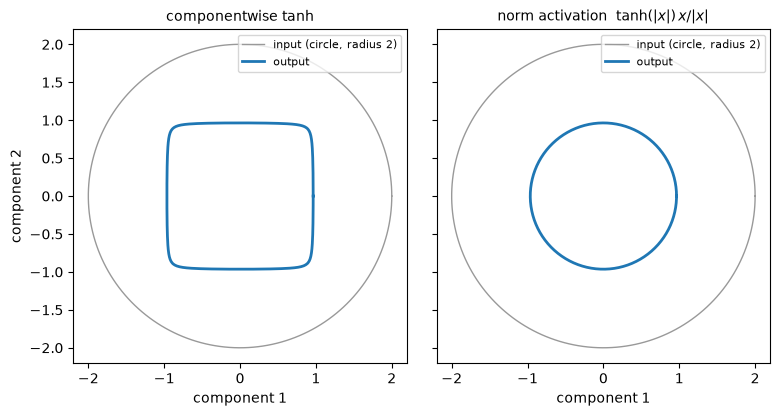

In [4]:
# visualize: feed a circle of vectors (radius 2) through both nonlinearities

# Create a circle of vectors in the xy-plane with radius 2
theta = torch.linspace(0, 2 * torch.pi, 200)

# Create a batch of 200 vectors on the circle in the xy-plane
# (200, 3) vectors, 3rd components are 0
circle = torch.stack(
    [2 * torch.cos(theta), 2 * torch.sin(theta), torch.zeros_like(theta)], dim=-1
) 

# Apply the componentwise tanh and the norm activation to the circle of vectors
tanh_img = torch.tanh(circle)
norm_img = enn.NormActivation("1x1o", torch.tanh)(circle)  # tanh(|x|) x/|x|

# Plot the results of both nonlinearities
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
for ax, img, name in [
    (axes[0], tanh_img, "componentwise tanh"),
    (axes[1], norm_img, r"norm activation  $\tanh(|x|)\,x/|x|$"),
]:
    ax.plot(
        circle[:, 0], circle[:, 1], color="0.6", lw=1, label="input (circle, radius 2)"
    )
    ax.plot(img[:, 0], img[:, 1], color="C0", lw=2, label="output")
    ax.set_aspect("equal")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("component 1")
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("component 2")
fig.tight_layout()
plt.show()

The input circle is mapped to itself by any rotation about its center, so an
equivariant map must send it to another rotationally symmetric curve. The norm
activation does (right: a smaller circle). Componentwise tanh instead produces a
rounded *square* (left): it singles out the coordinate axes: the very axes
equivariance says must be meaningless.

Norm activations are perfectly legitimate and appear in real architectures.
However, Weiler et al. (2018) compared them against a third option and found it
to *"work in practice better"* and to converge faster than tensor-product
nonlinearities. That option is the **gated nonlinearity**, which is the standard
nonlinearity of NequIP, MACE, and most of Part IV of this course.

## The Gate

The **gated nonlinearity** was introduced by Weiler et al. in the [3D Steerable
CNNs
manuscript](https://proceedings.neurips.cc/paper_files/paper/2018/file/488e4104520c6aab692863cc1dba45af-Paper.pdf).
For each non-scalar feature, $f_i(x)$, the network produces one extra *scalar*
field $\gamma_i \star f(x)$ (in their voxel CNN: one more channel of the
preceding convolution), squashes it with a sigmoid $\sigma$, and rescales the
feature by it. That is,

$$ f_i(x) \;\longmapsto\; f_i(x)\, \sigma\big(\gamma_i \star f(x)\big). $$

The nonlinearity itself is parameter-free and manifestly equivariant: $\sigma$
only ever acts on a scalar, and *scalar $\times$ feature* is an allowed
tensor-product path ($0 \otimes l \to l$, Lesson 03a) that is realized
channel-by-channel in e3nn through the `ElementwiseTensorProduct` as shown in
Lesson 03b. Weiler et al. note that the gated nonlinearity can be read as a
special case of both the norm nonlinearity (it changes only the length) and the
tensor-product nonlinearity (one factor is a scalar).

The `e3nn.nn.Gate` enables this functionality together with ordinary activations
for the scalar features. Its five constructor arguments describe an input split
into three groups, $x = (s, g, v)$ with irreps `irreps_scalars + irreps_gates +
irreps_gated`:

| argument | contents |
|---|---|
| `irreps_scalars` | scalars $s$ that pass through their own activation ($l = 0$ only) |
| `act_scalars` | the activation(s) applied to $s$, one per entry of `irreps_scalars` |
| `irreps_gates` | scalars $g$ **consumed** in gate: total multiplicity must match `irreps_gated` |
| `act_gates` | activation(s) for the gates, typically `sigmoid` |
| `irreps_gated` | the $l > 0$ features $v$ being gated |

and computes (channel $u$ of the gated block, gate scalar $g_u$):

$$ \mathrm{Gate}(s, g, v) \;=\; \Big( \underbrace{\phi_s(s)}_{\text{activated scalars}},\; \underbrace{\phi_g(g_u)\, v_u}_{\text{gated features}} \Big),
\qquad \mathtt{irreps\_out} = \mathtt{irreps\_scalars} + \mathtt{irreps\_gated}.
$$

Note the bookkeeping: the gate scalars appear in `irreps_in` but **not** in
`irreps_out`: they are consumed. The layer *feeding* a Gate must therefore
produce those extra `0e` channels (in Lesson 08, NequIP's convolution does
exactly this).

Let us see an example of a Gate in action.

In [5]:
# Create a Gate that takes 8 scalars, 4 gate scalars, and 2+2 non-scalar channels
gate = enn.Gate(
    "8x0e", [torch.nn.functional.silu],   # s: 8 scalars through SiLU
    "4x0e", [torch.sigmoid],              # g: 4 gate scalars through sigmoid ...
    "2x1o + 2x2e",                        # v: ... gating 2+2 = 4 non-scalar channels
)
print(gate)
print("irreps_in :", gate.irreps_in)
print("irreps_out:", gate.irreps_out, "  <- the 4x0e gates are consumed")
print(f"parameters: {sum(p.numel() for p in gate.parameters())}  (the Gate itself learns nothing)")
assert_equivariant(gate, gate.irreps_in, gate.irreps_out)

Gate (12x0e+2x1o+2x2e -> 8x0e+2x1o+2x2e)
irreps_in : 12x0e+2x1o+2x2e
irreps_out: 8x0e+2x1o+2x2e   <- the 4x0e gates are consumed
parameters: 0  (the Gate itself learns nothing)
equivariant!  (max error 8.882e-16 over random O(3) elements)


8.881784197001252e-16

### The Gate, reproduced by hand

One subtlety before we replicate it: like all e3nn activations, the functions
you pass in are silently wrapped with `e3nn.math.normalize2mom`, which rescales
them by a fixed constant so that their output has unit second moment for
standard-normal inputs. That is, $\mathbb{E}_{z \sim \mathcal{N}(0,1)}
[\varphi(z)^2] = 1$. This is the same variance bookkeeping as the `path_weight`
constants of Lesson 03b. Note that **every e3nn layer preserves unit variance
in, unit variance out**.

In [6]:
# The hidden rescaling inside every e3nn activation
from e3nn.math import normalize2mom

# Create a batch of 16 random inputs from the Gate, with the correct number of channels
x = gate.irreps_in.randn(16, -1)

# Scalars | gates | gated (2x1o: 6  +  2x2e: 10)
s, g, v = x.split([8, 4, 16], dim=-1)

# Reproduce the Gate by hand:  phi_s(s), phi_g(g) * v  per channel   (the gate equation)

# Activated scalars
phi_s = normalize2mom(torch.nn.functional.silu)(s)

# Activated gates
phi_g = normalize2mom(torch.sigmoid)(g)

# Gate u multiplies channel u
gated_1o = v[:, :6].reshape(16, 2, 3) * phi_g[:, 0:2, None]
gated_2e = v[:, 6:].reshape(16, 2, 5) * phi_g[:, 2:4, None]

# Concatenate the activated scalars and the gated features to form the manual output
manual = torch.cat([phi_s, gated_1o.reshape(16, 6), gated_2e.reshape(16, 10)], dim=-1)
print("Gate == ( phi_s(s), phi_g(g) * v ) :", torch.allclose(gate(x), manual))

Gate == ( phi_s(s), phi_g(g) * v ) : True


Let us now see how the `normalize2mom` wrapper impacts the sigmoid and tanh
functions visually.

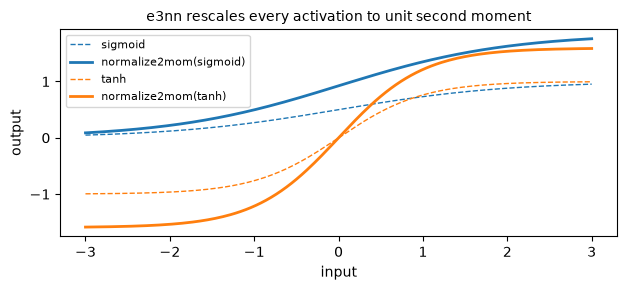

In [7]:
# Create a grid of input points for the activations
z = torch.linspace(-3, 3, 200)

# Visualize the effect of normalize2mom on the sigmoid and tanh functions
fig, ax = plt.subplots(figsize=(6.5, 3))
for f, name, c in [(torch.sigmoid, "sigmoid", "C0"), (torch.tanh, "tanh", "C1")]:
    ax.plot(z, f(z), color=c, ls="--", lw=1, label=name)
    ax.plot(z, normalize2mom(f)(z), color=c, lw=2, label=f"normalize2mom({name})")
ax.set_xlabel("input")
ax.set_ylabel("output")
ax.set_title("e3nn rescales every activation to unit second moment", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## The parity subtlety: even and odd scalars

The expression previously stated, "any function may act on a scalar", was not
entirely accurate. Under the $O(3)$ group, there are *two* kinds of scalars
(Lesson 02a): An even scalar, `0e`, which has $D(g) = 1$ for every $g$: any
$\varphi$ is fine; and an **odd scalar** (pseudoscalar), `0o`, which
is invariant under rotations but **flips sign under inversion**: $D(R) = 1$, $D(P)
= -1$. Equivariance of a pointwise $\varphi$ on `0o` requires that

$$ \varphi(-x) = -\varphi(x) \qquad \rightarrow \qquad \varphi \text{ must be an odd function.} $$

As such, for example:

- $\tanh$, $\sin$, and $x^3$ are odd functions. So, the output is again `0o`.
- $|x|$, $\cos$, and $x^2$ are even functions. Their usage is allowed, but the
  output becomes an **even** scalar, `0e`, which means the sign information is
  destroyed as parities multiply: $o \times o = e$.
- sigmoid, ReLU, SiLU are **neither** even nor odd functions. No output parity
  makes them equivariant. They break the $O(3)$ symmetry.

Note that rotations never flip a pseudoscalar, so every test based on $SO(3)$
operations passes and the bug is invisible until a reflected/inverted structure
is used (recall Lesson 01a: chirality!). Our harness exposes it via its `parity`
flag, which toggles whether random group elements include the inversion:

In [8]:
# The parity subtlety test
for act, name in [(torch.tanh, "tanh (odd)"), (torch.sigmoid, "sigmoid (neither)")]:
    
    # Rotations only
    err_so3 = equivariance_error(act, "0o", "0o", parity=False, n_trials=20)
    
    # Rotations + inversion
    err_o3 = equivariance_error(act, "0o", "0o", parity=True, n_trials=20)
    print(f"{name:22s} on 0o:   SO(3) error = {err_so3:.1e}    O(3) error = {err_o3:.1e}")

tanh (odd)             on 0o:   SO(3) error = 0.0e+00    O(3) error = 0.0e+00
sigmoid (neither)      on 0o:   SO(3) error = 0.0e+00    O(3) error = 1.0e+00


Sigmoid acting on a pseudoscalar is *exactly* $SO(3)$-equivariant and
catastrophically wrong under $O(3)$. The e3nn's `Activation` (the module `Gate`
uses internally for `act_scalars`/`act_gates`) refuses to let this happen: it
probes your function's parity at construction time and either tracks the output
parity or raises an exception:

In [9]:
# E3nn refuses to let you apply a non-odd function to a pseudoscalar
try:
    enn.Activation("0o", [torch.sigmoid])
except ValueError as e:
    print("e3nn refuses:", e)

print("tanh on 0o ->", enn.Activation("0o", [torch.tanh]).irreps_out, "  (odd fn: parity kept)")
print("cos  on 0o ->", enn.Activation("0o", [torch.cos]).irreps_out, "  (even fn: parity flipped!)")

# The same algebra in the Gate: gating 1o features with 0o gates yields 1e outputs (o x o = e)
gate_odd = enn.Gate("0e", [torch.tanh], "4x0o", [torch.tanh], "4x1o")
print("odd gates:", gate_odd.irreps_in, "->", gate_odd.irreps_out)

# Check that it is equivariant
assert_equivariant(gate_odd, gate_odd.irreps_in, gate_odd.irreps_out)

e3nn refuses: Activation: the parity is violated! The input scalar is odd but the activation is neither even nor odd.
tanh on 0o -> 1x0o   (odd fn: parity kept)
cos  on 0o -> 1x0e   (even fn: parity flipped!)
odd gates: 4x0o+1x0e+4x1o -> 1x0e+4x1e
equivariant!  (max error 8.882e-16 over random O(3) elements)


8.881784197001252e-16

## An equivariant MLP, end to end

We are now familiar with every ingredient of a full equivariant network:
`o3.Linear`, the Gate, and an invariant readout via a tensor product. Let us
assemble them and put the central promise of the course- *"invariance by
construction beats augmentation"*- to a quantitative test.

### Task

For a point cloud $\{\vec r_1, \dots, \vec r_N\}$, predict the squared norm of
its traceless second-moment (quadrupole) tensor, $Q$, such that

$$ X_i = \vec r_i - \bar{\vec r}, \qquad Q = \sum_{i=1}^N \Big( X_i X_i^\top - \tfrac{1}{3} |X_i|^2\, \mathbb{1} \Big), \qquad y = \| Q \|_F^2 . $$

Note that under $g = (R, t)$ operations, we have $X_i \to R X_i$, such that $Q
\to R Q R^\top$. Furthermore, this transformation leaves $y$ unchanged because
it is an $E(3)$ **invariant** quantity (even under inversion, since $Q$ is
quadratic in $X$).

### Equivariant embedding

The network needs a fixed-size equivariant description of the cloud. As in
Lesson 02b, we embed *directions* with spherical harmonics, weight them by
powers of the invariant radius, and sum over points (sums are
permutation-invariant):

$$ h^{(k)} = \frac{1}{\sqrt N} \sum_{i=1}^N |X_i|^k\; Y\big(\hat X_i\big), \qquad k \in \{1, 2\}, \qquad Y = \big(Y^{(0)}, Y^{(1)}, Y^{(2)}\big) . $$

Note that the hat denotes normalization to unit length, $\hat X_i = X_i /
|X_i|$, and $Y^{(l)}$ are the spherical harmonics of degree $l$ (Lesson 02b).

Each moment $h^{(k)}$ carries irreps `0e + 1o + 2e` (parities $(-1)^l$, Lesson
02b), so the full embedding $h = (h^{(1)}, h^{(2)})$ has `irreps_emb = 2 x (0e +
1o + 2e)`. This "sum of radially-weighted harmonics" is the core concept of the
density trick behind ACE and MACE (Lesson 10). Note that the five components of
$Q$ are, up to a constant, exactly the $l = 2$ part of $h^{(2)}$: so, an exact
solution exists inside our model class, but the network has to find (learn) it
from the data.

### Architecture

Two Linear $\rightarrow$ Gate blocks, then an invariant readout that couples the
hidden features with themselves into `0e` (only $l \otimes l \to 0$ paths
survive: the readout is a learnable combination of invariant dot products):

$$ h_1 = \mathrm{Gate}(W_1\, h), \qquad h_2 = \mathrm{Gate}(W_2\, h_1), \qquad \hat y = \big( h_2 \otimes_w h_2 \big)_{0e} . $$

### Implementation

OK. Problem's defined, architecture's chosen, and the harness is ready. Let us
get into the coding part. First, let us focus on creating the train/test dataset

In [10]:
# Seed the random number generator for reproducibility
torch.manual_seed(0)

# Points per cloud
N = 8

# Number of training and test clouds
B_train, B_test = 256, 128

# Create a tiny dataset of random clouds
pos_train = torch.randn(B_train, N, 3)    
pos_test = torch.randn(B_test, N, 3)

and the target function.

In [11]:
# Define the target function: the squared Frobenius norm of the traceless part
# of the second moment tensor of the point cloud
def target(pos):
    
    # Center the point cloud by subtracting the mean position
    X = pos - pos.mean(1, keepdim=True)
    
    # sum_i X_i X_i^T
    Q = torch.einsum("bni,bnj->bij", X, X)
    
    # Subtract the trace to make it traceless
    Q = Q - torch.eye(3) * Q.diagonal(dim1=1, dim2=2).sum(-1)[:, None, None] / 3
    
    # y = ||Q||_F^2
    return (Q**2).sum((1, 2))

Now, we calculate the labels for our dataset. We then calculate the mean and
standard deviation of the labels and use them to standardize the labels. This is
a common practice in machine learning to improve the convergence of the training
process.

In [12]:
# Compute the target values for the training and test datasets
y_train, y_test = target(pos_train), target(pos_test)

# Compute the mean and standard deviation of the training labels
mu, sigma = y_train.mean(), y_train.std()

# Standardize the labels using the training statistics
y_train, y_test = (y_train - mu) / sigma, (y_test - mu) / sigma

# Create random rotation matrices for augmenting the test set
R = torch.stack([o3.rand_matrix() for _ in range(B_test)])

# The same test clouds in random orientations, never seen during training
pos_test_rot = torch.einsum("bij,bnj->bni", R, pos_test)
print("target is rotation-invariant, max |y(R pos) - y(pos)| =",
      f"{(target(pos_test_rot) - (y_test * sigma + mu)).abs().max().item():.2e}")

target is rotation-invariant, max |y(R pos) - y(pos)| = 1.14e-13


The dataset and target function are ready. The next step is to define the model architecture

In [13]:
# Seed the random number generator for reproducibility
torch.manual_seed(0)

# Spherical harmonic irreps: Y^(0), Y^(1), Y^(2)
sh_irreps = o3.Irreps("1x0e + 1x1o + 1x2e")

# Embedding irreps: two radial moments, k = 1 and k = 2
# Note: the l = 1 part of the k = 1 moment is sum_i r_i Y1(X_i-hat) = sum_i X_i, which
# centering forces to zero. Three of these 18 components are therefore structurally
# zero, and the 8 weights lin1 spends on that path never learn: the embedding really
# carries rank 15, not 18. Harmless here, but worth knowing when counting parameters.
irreps_emb = sh_irreps + sh_irreps

# Hidden irreps: 8 scalars, 8 vectors, 8 rank-2 tensors
irreps_hidden = o3.Irreps("8x0e + 8x1o + 8x2e")

# Define the equivariant MLP model
class EquivariantMLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Define the Gate that takes 8 scalars, 16 gate scalars, and 8+8 non-scalar channels
        make_gate = lambda: enn.Gate("8x0e", [torch.nn.functional.silu],   # Scalars
                                     "16x0e", [torch.sigmoid],             # 8+8 gate scalars
                                     "8x1o + 8x2e")                        # Gated features
        # Create two gates for the two hidden layers of the MLP
        self.gate1, self.gate2 = make_gate(), make_gate()
        # Produces the gates too!
        self.lin1 = o3.Linear(irreps_emb, self.gate1.irreps_in)
        self.lin2 = o3.Linear(irreps_hidden, self.gate2.irreps_in)
        # Readout layer: Fully connected tensor product to produce a scalar output
        self.readout = o3.FullyConnectedTensorProduct(irreps_hidden, irreps_hidden, "1x0e")

    # h^(k) = sum_i |X_i|^k Y(X_i-hat) / sqrt(N)
    def embed(self, pos):
        X = pos - pos.mean(-2, keepdim=True)
        r = X.norm(dim=-1, keepdim=True)
        Y = o3.spherical_harmonics([0, 1, 2], X, normalize=True, normalization="component")
        return torch.cat([(r * Y).sum(-2), (r**2 * Y).sum(-2)], dim=-1) / N**0.5

    def forward(self, pos):                          # pos: (B, N, 3) -> (B, 1)
        h = self.gate1(self.lin1(self.embed(pos)))   # h1 = Gate(W1 h)
        h = self.gate2(self.lin2(h))                 # h2 = Gate(W2 h1)
        return self.readout(h, h)                    # y-hat = (h2 (x) h2)_0e

# Create an instance of the EquivariantMLP model and print the number of parameters
model = EquivariantMLP()
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

Parameters: 592


Per course policy, we must test the equivariance BEFORE training. Here, the full
E(3) pipeline is tested with random rotations x inversion x translations on raw
positions

In [14]:
# Test on a batch of 8 point clouds
assert_model_equivariant(model, pos_test[:8], irreps_out="0e")

equivariant!  (max error 3.197e-14 over random O(3) + translations elements)


3.197442310920451e-14

### Training with zero data augmentation

In Lesson 01a, we saw that a plain MLP on flattened coordinates only
approximated invariance after heavy augmentation through rotation of the
training data, with a worst-case invariance error some fourteen orders of
magnitude above float64 round-off. 

Here, we train on each point cloud in a **single fixed orientation** and
evaluate on *randomly rotated* test clouds. The plain-MLP baseline below (same
spirit as Lesson 01a's model A, no augmentation) sees exactly the same data.

In [15]:
# Create a plain MLP that takes flattened coordinates as input and produces a scalar output
plain_mlp = torch.nn.Sequential(
    torch.nn.Linear(3 * N, 64), torch.nn.SiLU(),
    torch.nn.Linear(64, 64), torch.nn.SiLU(),
    torch.nn.Linear(64, 1),
)
print(f"plain MLP parameters: {sum(p.numel() for p in plain_mlp.parameters())}")

# Define a function to flatten and center the point cloud coordinates
def flatten_centered(pos):
    # Note that the plain MLP eats raw coordinates
    return (pos - pos.mean(1, keepdim=True)).reshape(len(pos), -1)

# Bookkeeping: store the networks and their corresponding feature extraction functions
nets = [("equivariant MLP", model, lambda p: p),
        ("plain MLP", plain_mlp, flatten_centered)]

# Train each network on the training data and record the losses
losses = {}
# Full-batch Adam, identical budgets
for name, net, feats in nets:
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    losses[name] = []
    for step in range(1000):
        opt.zero_grad()
        loss = torch.nn.functional.mse_loss(net(feats(pos_train)).squeeze(-1), y_train)
        loss.backward()
        opt.step()
        losses[name].append(loss.item())
    print(f"{name:18s} final train MSE = {losses[name][-1]:.2e}")

plain MLP parameters: 5825
equivariant MLP    final train MSE = 9.38e-04
plain MLP          final train MSE = 2.74e-05


Let us now calculate the mean absolute error (MAE) for each network on the
training set, test set, and rotated test set and comprare the results.

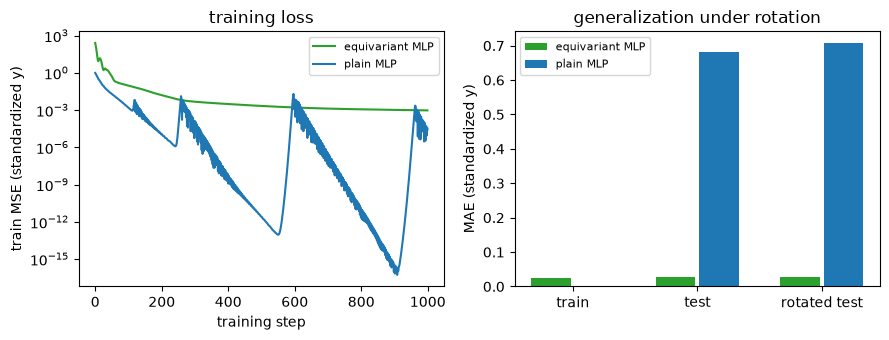

equivariant MLP    MAE:  train 0.0238   test 0.0262   rotated test 0.0262
plain MLP          MAE:  train 0.0009   test 0.6828   rotated test 0.7064


In [16]:
# Define a function to compute the mean absolute error (MAE) of a network on a
# given dataset
@torch.no_grad()
def mae(net, feats, pos, y):
    return (net(feats(pos)).squeeze(-1) - y).abs().mean().item()

# Compute the MAE for each network on the training set, test set, and rotated
# test set
results = {name: [mae(net, feats, pos_train, y_train),
                  mae(net, feats, pos_test, y_test),
                  mae(net, feats, pos_test_rot, y_test)] for name, net, feats in nets}

# Visualize the training losses and generalization errors for both networks
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
colors = {"equivariant MLP": "C2", "plain MLP": "C0"}
for name in losses:
    axes[0].plot(losses[name], color=colors[name], label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("train MSE (standardized y)")
axes[0].set_title("training loss")
axes[0].legend(fontsize=8)

xpos = torch.arange(3)
for k, name in enumerate(results):
    axes[1].bar(xpos + 0.35 * k - 0.175, results[name], width=0.32,
                color=colors[name], label=name)
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(["train", "test", "rotated test"])
axes[1].set_ylabel("MAE (standardized y)")
axes[1].set_title("generalization under rotation")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

# Print the MAE results for each network
for name, (tr, te, rot) in results.items():
    print(f"{name:18s} MAE:  train {tr:.4f}   test {te:.4f}   rotated test {rot:.4f}")

### Analyzing the results

The plain MLP memorizes its 256 training point cloud data (train MAE $\approx
0$) but it does not effectively transfer that *knowledge* to either fresh clouds
nor rotated ones in the testing sets: with $3N = 24$ unconstrained inputs, this
tiny dataset is hopeless. On the other hand, the equivariant MLP, with roughly
**10× fewer parameters** and **zero data augmentation** generalizes well and its
rotated-test MAE equals its test MAE on the original test set **to every printed
digit**. The invariance is not learned from the data, it is a property of the
architecture, exactly as in Lesson 01a's model C but now with a *learnable,
nonlinear* network. This data-efficiency gap is the same phenomenon NequIP
demonstrates on real molecules (Lesson 08).

## Summary

In this lesson we learned:

- A pointwise nonlinear activation acting on the components of an $l > 0$ irrep
  **cannot** be equivariant unless it becomes linear: rotations mix the feature
  components and $\varphi$ acts on them one by one. We have verified these by
  observing $O(1)$ error for tanh activation function acting on a `1x1o` irrep
  feature.
- Legal nonlinearities can act on **invariants**: any $\varphi$ can operate on
  `0e` scalars. We introduced the norm activation, $x \mapsto f(|x|)\, x / |x|$
  (`e3nn.nn.NormActivation`), and reproduced its action from scratch.
- The **Gate** : extra `0e` gate scalars, squashed and multiplied onto each $l >
  0$ channel by $\big(\phi_s(s),\, \phi_g(g_u)\, v_u\big)$. The gate has zero
  parameters and does not learn anything: it is a *nonlinearity* that is
  manifestly equivariant. The e3nn package wraps all activations with a
  `normalize2mom` to ensure all outputs have unit second moment for
  standard-normal inputs.
- **Parity**: Odd `0o` scalars admit only odd activations and even ones flip the
  output to `0e`. The sigmoid function acting on `0o` passes every $SO(3)$ test
  yet breaks $O(3)$: One should always test the equivariance with `parity=True`.
- A full equivariant MLP (`o3.Linear` $\rightarrow$ `Gate` $\rightarrow$
  `o3.Linear` $\rightarrow$ `Gate` $\rightarrow$ tensor-product readout) trained
  on unrotated clouds generalizes to rotated test data with zero augmentation,
  at $\approx$ 10x fewer parameters than a plain MLP, which fails to generalize.

Congratulations! You have come a long way and Part I is now complete. You are
now familiar with symmetry types (`Irreps`), embeddings (spherical harmonics),
linear/bilinear maps (tensor products), and nonlinearities (gates) which are
essential for building equivariant neural networks.

**Next:** In Lesson 05a we move from from point clouds to *graphs* and discuss
important concepts such as cutoff radii, neighbor lists, and periodic boundary
conditions, the data structures many interatomic potentials are built on.

## Exercises

**Exercise 1: Parity bookkeeping.** For each activation function, tanh, $\sin$,
$x^2$, $|x|$, sigmoid, acting on a single `0o` scalar, decide: is it allowed,
and what is the output parity? Verify each answer with `enn.Activation("0o",
[act])`.

<details><summary>Solution</summary>

Odd functions keep `0o`; even functions produce `0e`; sigmoid is neither and
e3nn must raise an exception for it.

```python
# Check the parity of each activation function acting on a 0o scalar
for act, name in [(torch.tanh, "tanh"), (torch.sin, "sin"),
                  (lambda x: x**2, "x^2"), (torch.abs, "|x|"), (torch.sigmoid, "sigmoid")]:
    try:
        print(f"{name:8s} -> {enn.Activation('0o', [act]).irreps_out}")
    except ValueError:
        print(f"{name:8s} -> ValueError (neither even nor odd)")

# Output:
# tanh -> 1x0o, sin -> 1x0o, x^2 -> 1x0e, |x| -> 1x0e, sigmoid -> ValueError
```
</details>

**Exercise 2: Norm activations instead of gates.** Rebuild the MLP of Section 5
with each Gate replaced by `enn.Activation` on the `8x0e` scalars plus
`enn.NormActivation` on the `8x1o + 8x2e` part (note: the Linears no longer need
to produce gate scalars). Check equivariance and retrain. How does it compare?

<details><summary>Solution</summary>

```python
class NormActMLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Linears produce only the scalars and gated features
        self.lin1 = o3.Linear(irreps_emb, irreps_hidden)
        self.lin2 = o3.Linear(irreps_hidden, irreps_hidden)
        # The scalars and gated features are activated separately
        self.act_s = enn.Activation("8x0e", [torch.nn.functional.silu])
        # NormActivation wants an Irreps object, not a string, when bias=True
        self.act_v = enn.NormActivation(o3.Irreps("8x1o + 8x2e"), torch.sigmoid, bias=True)
        # The readout is still a tensor product to 0e
        self.readout = o3.FullyConnectedTensorProduct(irreps_hidden, irreps_hidden, "1x0e")
        self.embed = model.embed # Reuse the embedding from the original model
    def act(self, h):
        return torch.cat([self.act_s(h[:, :8]), self.act_v(h[:, 8:])], dim=-1)

    def forward(self, pos):
        h = self.act(self.lin2(self.act(self.lin1(self.embed(pos)))))
        return self.readout(h, h)

# Instantiate the model and check equivariance on a small batch of test data
norm_model = NormActMLP()
assert_model_equivariant(norm_model, pos_test[:8], irreps_out="0e")

# ... then reuse the training loop.
```

At the same budget (1000 steps, lr 1e-2) this variant trains markedly worse:
test MAE around 4x the gated model's, and on some seeds it barely fits at all.
That is not a capacity limit, given roughly 8x the steps it reaches a lower
train MSE than the gated model. As `NormActivation` replaces each feature's
magnitude with $\text{sigmoid}(||v|| + b)$ and discards the scale, the target
($y = ||Q||_{F^2}$) becomes scale-sensitive. This is the trainability gap Weiler
et al. (2018) report, and why gates are the preferred choice for nonlinearity in
practice (e.g., in NequIP and MACE).

</details>

**Exercise 3: An *equivariant* output.** Change the readout to
`o3.FullyConnectedTensorProduct(irreps_hidden, irreps_hidden, "1x1o")` and train
the network to predict the vector $\vec p = \sum_i |X_i|^2 X_i$ (a `1o` quantity:
check its parity!). Verify with
`assert_model_equivariant(..., irreps_out="1o")` that predictions co-rotate with
the input.

<details><summary>Solution</summary>

The target property, $\vec p$, is odd under inversion ($X \to -X$ flips it) and
rotates as a vector: irrep `1o`. Note that $\vec p = \sum_i r_i^3 \hat X_i$ is the
$l = 1$ part of the $k = 3$ moment, while `embed` only builds $k = 1$ and $k = 2$:
unlike the scalar target of Section 5, this one is *not* exactly representable from
the embedding, so the training loss settles on a floor of roughly 1% of the target
variance. Equivariance is exact either way, which is what this exercise checks.

```python
# Define the target vector function
def target_vec(pos):
    X = pos - pos.mean(1, keepdim=True)
    # (B, 3), irreps 1o
    return ((X.norm(dim=-1, keepdim=True) ** 2) * X).sum(1)

# Instantiate the model
vec_model = EquivariantMLP()

# Inject the readout to produce a vector instead of a scalar. It stays a tensor
# product because forward() calls self.readout(h, h), with two arguments.
vec_model.readout = o3.FullyConnectedTensorProduct(irreps_hidden, irreps_hidden, "1x1o")

# Verify that the model is equivariant
assert_model_equivariant(vec_model, pos_test[:8], irreps_out="1o")

# Normalize the target vector for training
y_vec = target_vec(pos_train) / target_vec(pos_train).std()

# Define the optimizer
opt = torch.optim.Adam(vec_model.parameters(), lr=1e-2)

# Train the model for 600 steps
for step in range(600):
    opt.zero_grad()
    loss = torch.nn.functional.mse_loss(vec_model(pos_train), y_vec)
    loss.backward(); opt.step()
print(loss.item())   # settles near 0.01 -- the floor described above, not a bug

# ... and re-check equivariance after training!
```
</details>

## References

- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Weiler et al., *3D Steerable CNNs* NeurIPS (2018)](https://proceedings.neurips.cc/paper_files/paper/2018/file/488e4104520c6aab692863cc1dba45af-Paper.pdf)
- [Batzner et al., *NequIP: E(3)-equivariant GNNs for interatomic potentials* Nat. Commun. 13 2453 (2022)](https://doi.org/10.1038/s41467-022-29939-5)
